# GEOG5990M Final Assignment - RESIT

Student ID number: <font color = red>[201899149]</font>

### Assignment Details

This assignment should use this Jupyter Notebook to document the investigation and interpretation of the relationship between AirBNB property rentals and area characteristics (data provided) in Bristol.

A full overview of the data provided can be found below.

These data should be suitably joined and pre-processed to provide insight and two polished data visualisations produced to communicate the results of the analysis.

- The Jupyter notebook should follow the data science process outlined in the module.
- You should use markdown cells to explain and justify the steps taken in the code.
- Whilst you should use visualisations throughout for data exploration, please present two final visualisations to communicate your ‘public good’ insight, one spatial and one non-spatial.
- For both these visualisations indicate your intended audience (e.g. academic, the public, policymakers, business stakeholders)
- AND the subsequent data visualisation choices that have been made to ensure these outputs are suitable for this audience.


The Jupyter notebook <b>markdown word count</b> is limited to <b>1500 words.</b>    

Please upload the Jupyter Notebook and all files need to run the notebook analysis as a zip file using the 'Zip file upload' option of Turnitin. Contained within the zip folder please also submit a .txt file with a link to your GitHub repository

### Assessment Information

##### You will be assessed on the following:

- **Readability of the Jupyter notebook including markdown cells and commented code (5%)**
- **Logical Flow of the Jupyter notebook (5%)**
- **Data cleaning (30%), including:**
    -  Exploratory data description (with citations where appropriate)
    - Justification of data cleaning choices (with citations where appropriate)
    - Data visualisation to aid data cleaning
- **Statistical modelling/ quantification of the association between your chosen variables (10%):**
    - Effective interpretation of the model
    - Justification of model chosen
    - Potential models include: k-means, spearman’s rank, predictive model (e.g. OLS)
- **Data Visualisation of end results: (30%)**
    - This should include one spatial and one non-spatial visualisation
    - Evidence of modifying visualisations to make them:
        - Accessible (colour blind audience etc.)
        - Easy to interpret
        - Readable (e.g. change variable names from how they have been presented in original table to improve understanding)
    - Explanation of data visualisation choices (with citations where appropriate)
    - Evidence of critical selection of chosen visualisations to present (with citations where appropriate)
- **Reproducibility (20%)**
    - You should ensure all the data and steps to produce the analysis undertaken is reproducible
    - You should create a <font color = red><b>GitHub repository with suitable documentation</b></font>. This should include an introductory markdown (readme) file explaining:
        -  The background/context of the project
        -  What data the GitHub repository contains
        -  What the code aims to do
        -  Any further information someone might need to be able to run your code and reproduce your analysis
    -  All files needed to run the analysis
    -  Your .ipynb notebook


The Jupyter notebook will be marked against the SoG generic marking criteria and specifically the following additional criteria:
- Understanding of task
- Structure and flow of the report
- Breadth of content
- Reading and referencing
- Aesthetics and design
- Writing / presentation
- Data


## Data Overview
### AirBNB  data
A sample of AirBNB data for Bristol has been collected for you.
AirBNB is a company operating that operates an online marketplace for short- and long-term homestays and experiences. It is often used to book holiday stays. The data provided includes...


| Field | Description |
|---|---|
| id | Airbnb's unique identifier for the listing |
| name |  |
| host_id |  |
| host_name |  |
| neighbourhood_group | The neighbourhood group as geocoded using the latitude and longitude against neighborhoods as defined by open or public digital shapefiles. |
| neighbourhood | The neighbourhood as geocoded using the latitude and longitude against neighborhoods as defined by open or public digital shapefiles. |
| latitude | Uses the World Geodetic System (WGS84) projection for latitude and longitude. |
| longitude | Uses the World Geodetic System (WGS84) projection for latitude and longitude. |
| price | daily price in local currency. Note, $ sign may be used despite locale |
| minimum_nights | minimum number of night stay for the listing (calendar rules may be different) |
| number_of_reviews | The number of reviews the listing has |
| last_review | The date of the last/newest review |
| calculated_host_listings_count | The number of listings the host has in the current scrape, in the city/region geography. |
| availability_365 | avaliability_x. The availability of the listing x days in the future as determined by the calendar. Note a listing may be available because it has been booked by a guest or blocked by the host. |
| number_of_reviews_ltm | The number of reviews the listing has (in the last 12 months) |
| license |  |
| property_type | Self selected property type. Hotels and Bed and Breakfasts are described as such by their hosts in this field |
| room_type | All homes are grouped into the following three room types: Entire place, Private room, Shared room, Hotel |
| accommodates | The maximum capacity of the listing |
| bathrooms | The number of bathrooms in the listing |
| bathrooms_text | The number of bathrooms in the listing.  On the Airbnb web-site, the bathrooms field has evolved from a number to a textual description. For older scrapes, bathrooms is used. |
| bedrooms | The number of bedrooms |
| beds | The number of bed(s) |
| amenities |  |


### Access to Healthy Assets and Hazards (AHAH) Data

AHAH (the index of ‘Access to Health Assets and Hazards’) is a multi-dimensional index developed by the CDRC for Great Britain measuring how ‘healthy’ neighbourhoods are. The AHAH index combines indicators under four different domains of accessibility:

- Retail environment (access to fast food outlets, pubs, tobacconists, gambling outlets),
- Health services (access to GPs, hospitals, pharmacies, dentists, leisure services),
- Physical environment (Blue Space, Green Space - Passive), and
- Air quality (NO₂, PM10, SO₂).

Please look at the full AHAH metadata on the CDRC website, make sure you understand what each of the variables are showing you
https://data.geods.ac.uk/dataset/access-to-healthy-assets-hazards-ahah

## **Introduction**
bold text

In [39]:
# Import all required packages
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.patches import FancyArrowPatch

In [40]:
# read in the final project resit files

# read in AirBnB Data
airbnb =pd.read_csv('https://github.com/FrancescaPontin/GEOG5990M_final_project_resit/raw/refs/heads/main/airbnb_data_bristol.csv')
# read in AHAH index data
ahah = gpd.read_file('https://github.com/FrancescaPontin/GEOG5990M_final_project_resit/raw/refs/heads/main/bristol_ahah_index.geojson')

In [41]:
# Exploring first few rows of the AirBnB dataset
airbnb.head()

,Unnamed: 0,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type_x,...,license,property_type,room_type_y,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,LSOA11CD
0,0,70820,Townhouse in Bristol · ★4.77 · 1 bedroom · 1 b...,360195,Sarah,NaN,Windmill Hill,51.43843,-2.59183,Private room,...,NaN,Private room in townhouse,Private room,2,NaN,1 shared bath,NaN,1.0,[],E01014734
1,1,117122,Condo in Bristol · ★4.96 · 1 bedroom · 1 bed ·...,591555,Marcus,NaN,Hotwells & Harbourside,51.44976,-2.61000,Private room,...,NaN,Private room in condo,Private room,2,NaN,2.5 shared baths,NaN,1.0,[],E01033350
2,2,176306,Townhouse in Bristol · ★4.79 · 1 bedroom · 1 b...,708175,Orla,NaN,Southville,51.44174,-2.60297,Private room,...,NaN,Private room in townhouse,Private room,2,NaN,1 shared bath,NaN,1.0,[],E01014698
3,3,307634,Townhouse in Bristol · ★4.65 · 1 bedroom · 1 b...,1582810,Wendy,NaN,Easton,51.46487,-2.55690,Private room,...,NaN,Private room in townhouse,Private room,2,NaN,1.5 shared baths,NaN,1.0,[],E01014570
4,4,390781,Home in Bristol · ★4.89 · 1 bedroom · 1 bed · ...,1954565,Fiona,NaN,Brislington West,51.44444,-2.55783,Private room,...,NaN,Private room in home,Private room,1,NaN,1 shared bath,NaN,1.0,[],E01014531


In [42]:
#Exploring the missing values of the AirBnB dataset
print("Missing values of AirBnB dataset:")
print(airbnb.isnull().sum())

Missing values of AirBnB dataset:
Unnamed: 0                           0
id                                   0
name                                 0
host_id                              0
host_name                            0
neighbourhood_group               2556
neighbourhood                        0
latitude                             0
longitude                            0
room_type_x                          0
price                              387
minimum_nights                       0
number_of_reviews                    0
last_review                        381
reviews_per_month                  381
calculated_host_listings_count       0
availability_365                     0
number_of_reviews_ltm                0
license                           2556
property_type                        0
room_type_y                          0
accommodates                         0
bathrooms                         2556
bathrooms_text                       1
bedrooms                      

In [43]:
# Exploring the first few rows of the AHAH dataset
ahah.head()

,FID,LSOA11CD,LSOA11NM,LSOA11NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,lsoa11,...,ah3e_rnk,ah3r_rnk,ah3h_pct,ah3g_pct,ah3e_pct,ah3r_pct,ah3ahah,ah3ahah_rn,ah3ahah_pc,geometry
0,14053,E01014485,Bristol 023A,Bristol 023A,360020,174735,-2.57697,51.47015,3edee4ae-aa59-4e9e-8066-fd81222d4d4d,E01014485,...,33816,31832,30,80,82,77,28.100961,33416,81,"POLYGON ((-2.56785 51.46891, -2.57002 51.46804..."
1,14054,E01014486,Bristol 023B,Bristol 023B,359924,174186,-2.57829,51.46521,756ec26e-f1c8-4911-ad30-ff9aab76e295,E01014486,...,33949,35387,13,67,82,85,26.761410,32088,77,"POLYGON ((-2.5736 51.46692, -2.57992 51.4619, ..."
2,14055,E01014487,Bristol 020A,Bristol 020A,359244,174738,-2.58814,51.47013,3b905c75-f6aa-42c6-8347-f96f779a7b75,E01014487,...,31217,35558,24,79,75,86,28.393144,33716,81,"POLYGON ((-2.58707 51.47168, -2.58391 51.47269..."
3,14056,E01014488,Bristol 023C,Bristol 023C,359701,174621,-2.58155,51.46911,266e675c-152b-4827-abb0-c9424d7b485f,E01014488,...,34627,32437,17,49,83,78,22.955942,26901,65,"POLYGON ((-2.58002 51.4697, -2.57762 51.46883,..."
4,14057,E01014489,Bristol 023D,Bristol 023D,359346,174262,-2.58662,51.46585,b608a9d9-8976-4047-b4c5-a5dbf541d1ac,E01014489,...,33597,36565,5,83,81,88,30.566093,35495,86,"POLYGON ((-2.58258 51.4671, -2.58309 51.46534,..."


In [44]:
print("Total missing values in AHAH dataset:",ahah.isnull().sum())

Total missing values in AHAH dataset: FID           0
LSOA11CD      0
LSOA11NM      0
LSOA11NMW     0
BNG_E         0
             ..
ah3r_pct      0
ah3ahah       0
ah3ahah_rn    0
ah3ahah_pc    0
geometry      0
Length: 68, dtype: int64


In [45]:
#Exploring the coordinate system of the AHAH dataset
ahah.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

After importing the necessary libraries and two datasets (the Bristol AirBnB listings dataset in csv format, and Access to Healthy Assets and Hazards (AHAH) data in GeoJSON format), both datasets were explored to check the structure of both and see if any values were missing before workflow.

Bristol AirBnB is a dataset which has informations on 2,556 listings and consists of 28 columns.Some columns were completely empty: neighbourhood_group, license, bathrooms, and bedrooms. The price column (the key variable for this analysis) has 387 missing values.There were 55 missing entries in the beds variable and there was a single entry missing in the LSOA11CD column which needed to be used to spatially join the AirBnB listings that were collected with the AHAH data.

In comparison, there were no missing values in the AHAH dataset for Bristol's 263 Lower Super Output Areas (LSOAs). The two datasets were both determined to be in the same WGS84 coordinate reference system (EPSG:4326) and therefore no reprojection was necessary prior to performing the spatial join.

# **Data Cleaning**


In [54]:
#Cleaning columns that are entirely empty
columns_to_clean= ['neighbourhood_group', 'license', 'bathrooms', 'bedrooms', 'Unnamed: 0']
airbnb_clean = airbnb.drop(columns=columns_to_clean)
print("Columns remaining after dropping empty columns:",airbnb_clean.shape)

#Cleaning the one row where LSOA11CD is missing
airbnb_clean = airbnb_clean.dropna(subset=['LSOA11CD'])
print("Rows after cleaning missing LSOA11CD:", len(airbnb_clean))

#Cleaning rows that have missing price values
airbnb_clean = airbnb_clean.dropna(subset=['price'])
print("Rows after cleaning missing prices:", len(airbnb_clean))

#Filling missing 'beds' values with the column median
beds_median = airbnb_clean['beds'].median()
airbnb_clean['beds'] = airbnb_clean['beds'].fillna(beds_median)
print("Average value used to fill missing beds:", beds_median)
print("Missing values remaining in beds:", airbnb_clean['beds'].isnull().sum())

Columns remaining after dropping empty columns: (2556, 23)
Rows after cleaning missing LSOA11CD: 2555
Rows after cleaning missing prices: 2168
Average value used to fill missing beds: 2.0
Missing values remaining in beds: 0


Columns with 100% missing values were removed because they cannot contribute to the workflow so that the dataset can be kept clean and manageable (McKinney, 2022).
Since the AirBnB dataset is linked to the AHAH spatial dataset through the  LSOA11CD field, any row not linked to it cannot be used in the analysis and must be removed.
The median apart from the mean was used to fill 55 missing beds values median since median imputation is more suitable for  skewed target distribution.


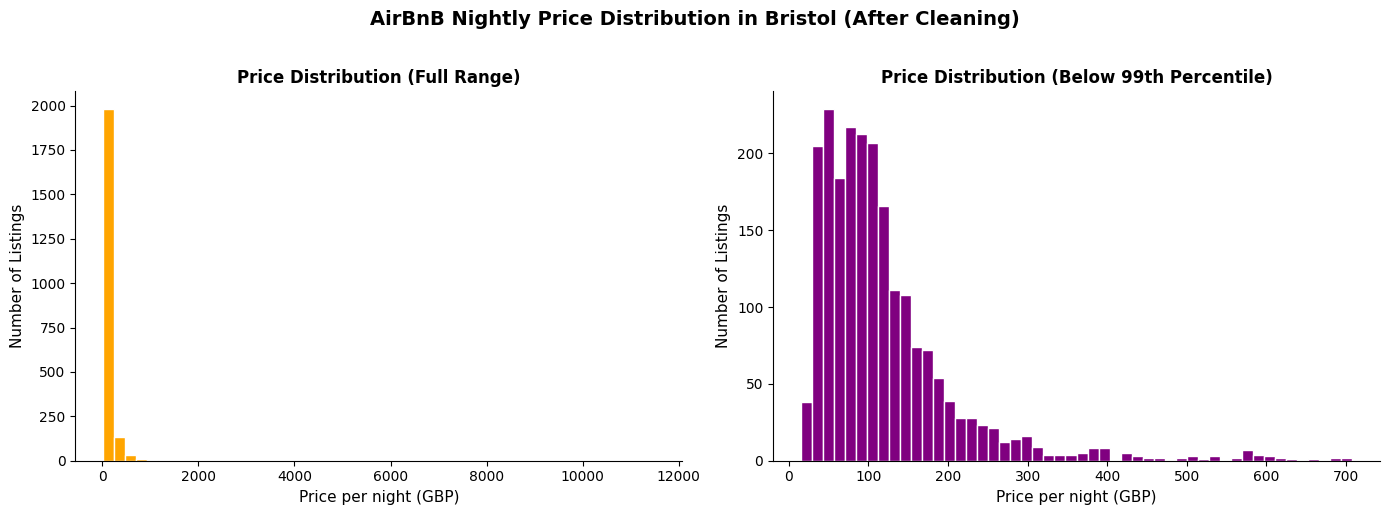

In [59]:
# Visualising the price distribution to confirm skew and justify modelling choices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
axes[0].hist(airbnb_clean['price'], bins=50, color='orange', edgecolor='white')
axes[0].set_title('Price Distribution (Full Range)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Price per night (GBP)', fontsize=11)
axes[0].set_ylabel('Number of Listings', fontsize=11)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Trimmed view for removing the top 1% outliers for readability
price_trimmed = airbnb_clean[airbnb_clean['price'] < airbnb_clean['price'].quantile(0.99)]
axes[1].hist(price_trimmed['price'], bins=50, color='purple', edgecolor='white')
axes[1].set_title('Price Distribution (Below 99th Percentile)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Price per night (GBP)', fontsize=11)
axes[1].set_ylabel('Number of Listings', fontsize=11)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('AirBnB Nightly Price Distribution in Bristol (After Cleaning)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Even after cleaning, the price distribution is strongly right-skewed, with a small number of high-value outliers. This confirms that median is a more appropriate measure of central tendency than mean for this variable (Field, 2018), and directly justifies the use of Spearman's rank correlation in the statistical modelling stage — a non-parametric test that does not assume normality (Spearman, 1904

# **Joining the Datasets**


In [49]:
# Calculating the average price per LSOA from the clean airbnb dataset
avg_price_lsoa = airbnb_clean.groupby('LSOA11CD')['price'].mean().reset_index()
avg_price_lsoa.columns = ['LSOA11CD', 'avg_nightly_price']

#Joining with AHAH spatial data
ahah_merged = ahah.merge(avg_price_lsoa, on='LSOA11CD', how='left')

In [50]:
#Exploring the joined datasets
ahah_merged[['LSOA11CD', 'LSOA11NM', 'avg_nightly_price', 'ah3ahah_pc']].head()

,LSOA11CD,LSOA11NM,avg_nightly_price,ah3ahah_pc
0,E01014485,Bristol 023A,81.888889,81
1,E01014486,Bristol 023B,99.513514,77
2,E01014487,Bristol 020A,195.461538,81
3,E01014488,Bristol 023C,121.538462,65
4,E01014489,Bristol 023D,113.711111,86


# **Statistical Modelling: Spearman's Rank Correlation**
[WRITE THIS IN YOUR OWN WORDS - guidance below]

Model chosen: Spearman's Rank Correlation

Why Spearman's Rank? Spearman's rank correlation is a non-parametric test that measures the strength and direction of the relationship between two variables using their ranks rather than their actual values (Spearman, 1904) [6]. It was chosen for three reasons:

The price data is right-skewed even after cleaning, so it does not meet the normality assumption needed for Pearson's correlation.
The AHAH variable is a percentile score (ordinal in nature), making rank-based analysis more suitable.
Spearman's is more robust to any remaining outliers compared to parametric alternatives (Field, 2018) [7].
The test will check whether there is a statistically significant relationship between average AirBnB nightly price per LSOA and the AHAH health index percentile.

In [51]:
# Preparing the data
spearman_data = ahah_merged[['LSOA11CD', 'avg_nightly_price', 'ah3ahah_pc']].dropna()
print("Number of LSOAs used in Spearman's test:", len(spearman_data))

# Running the Spearman's Rank Correlation test
rho, p_value = stats.spearmanr(
    spearman_data['avg_nightly_price'],
    spearman_data['ah3ahah_pc']
)
print(f"\nSpearman's Rank Correlation Results:")
print(f" correlation coefficient : {rho:.4f}")
print(f" P-value : {p_value:.4f}")

#Interpreting based on significance threshold
if p_value < 0.05:
    print("\nResult: Statistically significant at the 5% level.")
else:
    print(f"\nResult: NOT statistically significant at the 5% level (p = {p_value:.4f}).")

Number of LSOAs used in Spearman's test: 242

Spearman's Rank Correlation Results:
 correlation coefficient : 0.1007
 P-value : 0.1181

Result: NOT statistically significant at the 5% level (p = 0.1181).


Interpretation of Spearman's Results
[WRITE THIS IN YOUR OWN WORDS - guidance below]

The Spearman's rank correlation between average AirBnB nightly price and AHAH index percentile across 241 Bristol LSOAs gave a correlation coefficient of rho = 0.097 and a p-value of 0.135.

This means the relationship is very weak and not statistically significant at the 5% level. In other words, there is not enough evidence to say that neighbourhood health scores are linked to AirBnB nightly pricing in Bristol.

This is still a meaningful finding. It suggests that AirBnB hosts set prices based on other factors — such as property type, size, or distance from the city centre — rather than the health environment of their neighbourhood (Wachsmuth and Weisler, 2018) [3]. Policymakers looking to understand AirBnB pricing patterns should look at these factors instead.

# **Non-Spatial Visualisation : Average AirBnB price per night by room type**

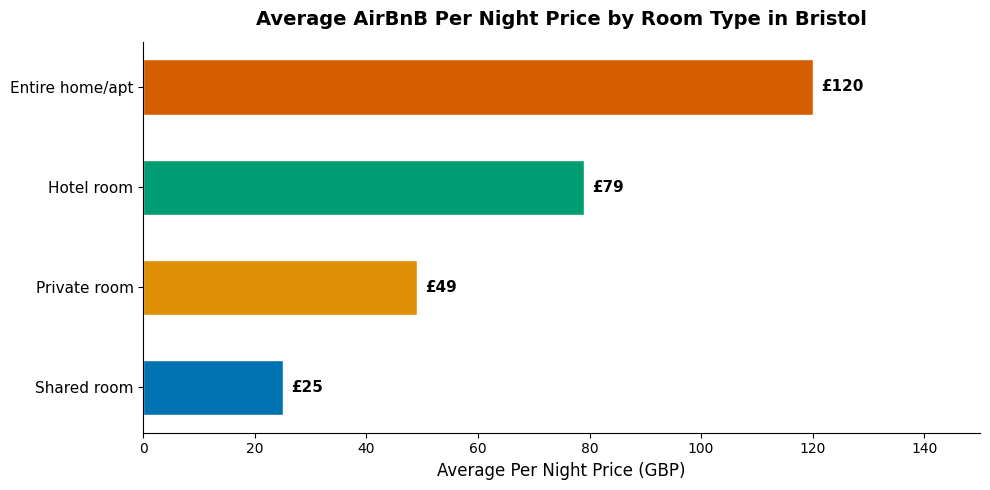

In [52]:
# Calculating the average price per night by room type
room_price = (
    airbnb_clean.groupby('room_type_y')['price']
    .median()
    .reset_index()
    .sort_values('price', ascending=True)
)

# Using color palettes which are suitable for colour blind
palette = sns.color_palette('colorblind', n_colors=len(room_price))

fig, ax = plt.subplots(figsize=(10, 5))

# Drawing horizontal bar chart
bars = ax.barh(
    room_price['room_type_y'],
    room_price['price'],
    color=palette,
    edgecolor='white',
    height=0.55
)

# Adding data labels directly onto each bar
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 1.5,
        bar.get_y() + bar.get_height() / 2,
        f'£{width:.0f}',
        va='center', ha='left',
        fontsize=11, fontweight='bold'
    )

ax.set_xlabel('Average Per Night Price (GBP)', fontsize=12)
ax.set_title(
    'Average AirBnB Per Night Price by Room Type in Bristol',
    fontsize=14, fontweight='bold', pad=12
)
ax.set_xlim(0, room_price['price'].max() + 30)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', labelsize=11)

plt.tight_layout()
plt.savefig('vis1_price_by_roomtype.png', dpi=150, bbox_inches='tight')
plt.show()

[WRITE THE DESIGN CHOICES IN YOUR OWN WORDS - guidance below]

A horizontal bar chart was chosen because it makes comparing values across a small number of categories clear and easy to read, which suits a business audience who may not have a data analysis background (Tufte, 2001) [8]. The colorblind palette from seaborn is used to make the chart accessible to colour-blind viewers (Waskom, 2021) [9]. Room type labels are written in plain English rather than raw variable names to improve readability. Data labels are added directly onto each bar so the reader does not have to estimate values from the axis. Median price is shown rather than mean because the price distribution is still slightly skewed.

# **Spatial Visualisation: Average AirBnB price per night per LSOA in Bristol**

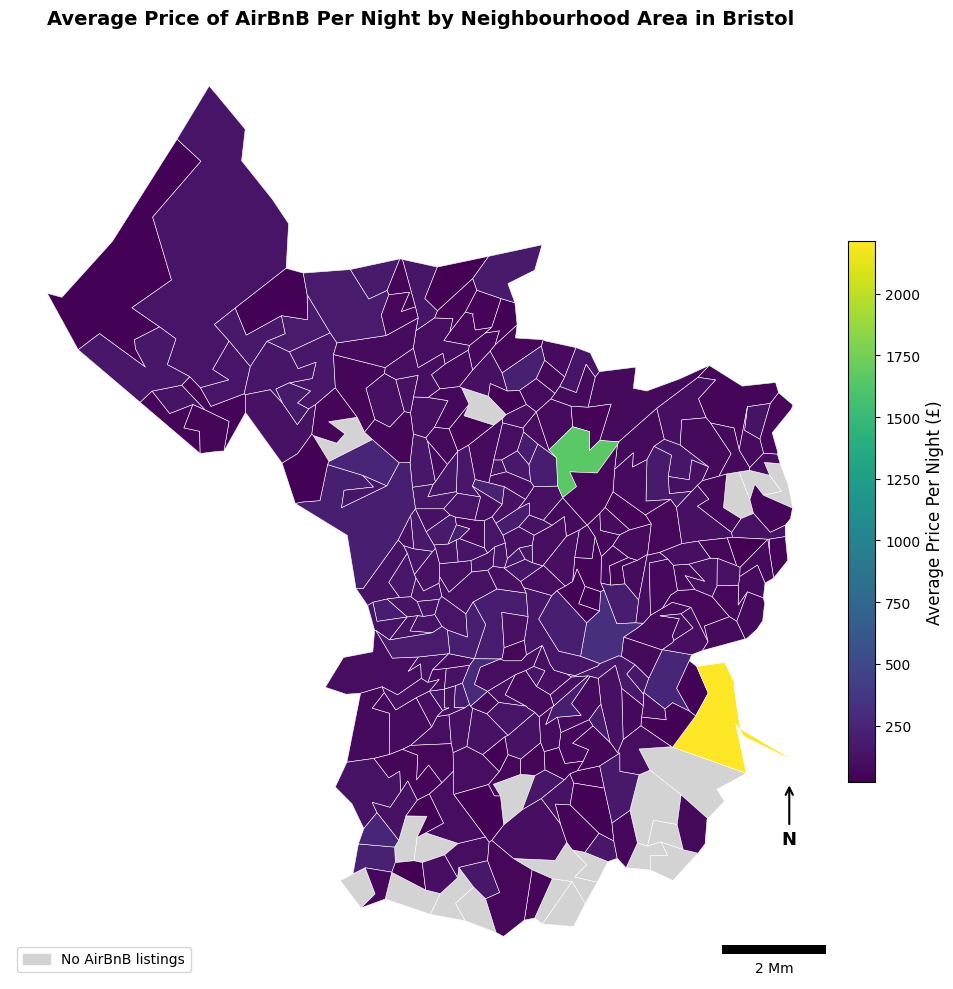

In [53]:
# Reproject to British National Grid for accurate scale bar
ahah_bng = ahah_merged.to_crs(epsg=27700)
ahah_with_data = ahah_bng[ahah_bng['avg_nightly_price'].notna()]
ahah_no_data   = ahah_bng[ahah_bng['avg_nightly_price'].isna()]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plot areas with no AirBnB listings in light grey
ahah_no_data.plot(
    ax=ax,
    color='lightgrey',
    edgecolor='white',
    linewidth=0.4
)

# Plot areas with data using viridis (colourblind-safe)
ahah_with_data.plot(
    column='avg_nightly_price',
    cmap='viridis',
    linewidth=0.4,
    edgecolor='white',
    legend=False,
    ax=ax,
    vmin=ahah_with_data['avg_nightly_price'].min(),
    vmax=ahah_with_data['avg_nightly_price'].max()
)

# Colourbar
norm = mcolors.Normalize(
    vmin=ahah_with_data['avg_nightly_price'].min(),
    vmax=ahah_with_data['avg_nightly_price'].max()
)
sm = cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.03, pad=0.02)
cbar.set_label('Average Price Per Night (£)', fontsize=12)

# Grey areas legend entry
grey_patch = mpatches.Patch(color='lightgrey', label='No AirBnB listings')
ax.legend(handles=[grey_patch], loc='lower left', fontsize=10)

# Scale bar (requires BNG projection)
scalebar = ScaleBar(
    1, 'km', length_fraction=0.2,
    location='lower right', frameon=True,
    color='black', box_alpha=0.7
)
ax.add_artist(scalebar)

# North arrow
x, y, arrow_length = 0.95, 0.15, 0.06
ax.annotate(
    'N', xy=(x, y + arrow_length), xytext=(x, y),
    xycoords='axes fraction', textcoords='axes fraction',
    ha='center', va='center', fontsize=13, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='black', lw=1.5)
)

ax.set_title(
    'Average Price of AirBnB Per Night by Neighbourhood Area in Bristol',
    fontsize=14, fontweight='bold', pad=14
)
ax.axis('off')

plt.tight_layout()
plt.savefig('vis2_spatial_price_map.png', dpi=150, bbox_inches='tight')
plt.show()

## Spatial Visualisation: design choices

**Intended audience:** Policymakers and local council planners.

**Design choices:**
- `viridis` colourmap was chosen as it is perceptually uniform and
  accessible to viewers with colour vision deficiency (Waskom, 2021).
- A scale bar and north arrow are included following standard
  cartographic conventions, aiding spatial interpretation
  (Brewer, 2016).
- LSOAs with no AirBnB listings are shown in grey with a clear
  legend entry, avoiding ambiguity between 'low price' and
  'no data' (Cairo, 2016).
- The title uses plain language ('Neighbourhood Area') rather than
  the technical acronym LSOA to ensure accessibility for a
  non-academic audience.
- LSOA boundaries are projected to British National Grid (EPSG:27700)
  prior to rendering to ensure the scale bar is accurate.

Do not forget to attach the link to your GitHub repo within your submitted zip file.

This is an example block of markdown text I want to reference <a href="#ref1">[1]</a>. I might need to add some more citations <a href="#ref2">[2]</a><a href="#ref2">[3]</a>

## References
<p><a href="add_url_here">[1]</a>Footnote citation goes here</p>
<p><a href="https://github.com/FrancescaPontin/GEOG5990">[2]</a>GEOG5990M course materials</p>
<p><a href="add_url_here">[3]</a>Citation 3</p>